# Notebook 06 — Hedge-Efficiency Frontiers (Uncertainty-Aware)

## Executive Summary

This notebook produces the **definitive hedge comparison** for perpetual-futures funding-rate risk. It answers: *which derivative structure provides the best capital efficiency for a carry position, and how confident can we be in that answer?*

**Design principles (motivated by Notebooks 04b, 05b, 05c):**

- **30-day horizon is the flagship**; 7d and 90d are included as appendix.
- All results carry **three uncertainty layers**: bootstrap sampling, era nonstationarity, and episode-model scenario bands.
- Model outputs are **scenario bands, not predictions** — NB05c demonstrates that calibrating on one era fails on another (1/7, 1/7, 4/7 OOS gates), confirming the process is nonstationary.
- A **walk-forward protocol** evaluates deployment realism: trailing-window calibration each month, no lookahead.
- Capital efficiency is framed via two formal definitions: reserve reduction per unit premium ($\text{Eff}_A$) and total economic cost ($\text{Cost}_B$).

## 1. Setup and Frozen Contract Specs

We load the Bybit primary funding series and define the full strategy set. All product parameters were frozen in Phase 5 (NB03) based on empirical calibration. The cap of $\pm 0.00375$ per 8h ($\pm 410.6\%$ APR) is a venue-level bound that truncates tail severity.

The **hedge ratio** $h \in \{0.0, 0.1, \ldots, 1.0\}$ scales both payoff and premium linearly, sweeping out a cost-vs-risk frontier for each strategy.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve repo root robustly across Jupyter environments
try:
    _nb_path = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    _nb_path = Path.cwd()
    if _nb_path.name == "notebooks":
        _nb_path = _nb_path.parent
import os; os.chdir(str(_nb_path))
REPO_ROOT = Path(os.getcwd()).resolve()
os.makedirs(str(REPO_ROOT / "reports" / "figures"), exist_ok=True)

from ddx.data.io import load_processed
from ddx.backtest.rolling import rolling_windows_regular
from ddx.backtest.hedges import estimate_swap_rate, swap_hedge_cf, swap_hedge_loss
from ddx.payoffs import vanilla_floor, distress_activated_floor, aggregate_stop_loss
from ddx.pricing.premium import compute_premium, full_premium
from ddx.risk.metrics import total_loss, var, cvar, cvar_right, prob_loss
from ddx.capital import reserve_requirement, efficiency_A, total_economic_cost, swap_margin_proxy
from ddx.models.cluster_semi_markov import extract_episodes_and_clusters, fit_cluster_tail, simulate_semi_markov
from ddx.calibration import lambda_quantiles_per_horizon, daf_activation_analysis
from ddx.bootstrap import circular_block_bootstrap, _vectorized_floor_payoffs, _vectorized_asl_payoffs, _vectorized_daf_payoffs
from ddx.utils.units import to_apr_pct, to_pct_notional, INTERVALS_PER_YEAR

df = load_processed("data/processed/bybit_btcusd.parquet")
funding_cf = df["funding_cf"].values
is_regular = df["is_regular"].values
timestamps = pd.to_datetime(df["timestamp"])
n_total = len(funding_cf)

HORIZON_30D = 90
HORIZON_7D = 21
HORIZON_90D = 270
ALPHA = 0.01
CAP = 0.00375

print(f"Bybit series: {n_total} intervals, {timestamps.iloc[0].date()} to {timestamps.iloc[-1].date()}")
print(f"Span: ~{n_total * 8 / (24 * 365):.1f} years")

Bybit series: 7971 intervals, 2018-11-15 to 2026-02-23
Span: ~7.3 years


### Strategy table

The strategies below cover the full product suite from Phase 5 calibration. ASL deductibles $D$ are calibrated per horizon as quantiles of the empirical $\Lambda$ distribution.

In [2]:
# --- Frozen baseline parameters (from Phase 5) ---
ASL_D_30D_Q90 = 0.008114
ASL_D_30D_Q95 = 0.012967
ASL_D_7D_Q90 = 0.001701
ASL_D_7D_Q95 = 0.003153
ASL_D_90D_Q90 = 0.023236
ASL_D_90D_Q95 = 0.029158

SWAP_LOOKBACK = 90
SWAP_HALFLIFE = 45

H_GRID = np.round(np.arange(0, 1.05, 0.1), 2)

strategy_table = pd.DataFrame([
    {"Strategy": "Unhedged", "Type": "—", "Parameters": "—", "Notes": "Baseline"},
    {"Strategy": "Swap (EWMA)", "Type": "Linear", "Parameters": "lookback=90, halflife=45", "Notes": "Primary swap"},
    {"Strategy": "Swap (mean)", "Type": "Linear", "Parameters": "lookback=90", "Notes": "Secondary swap"},
    {"Strategy": "Floor d=0.0001", "Type": "Option", "Parameters": "d=0.0001", "Notes": "Main Floor"},
    {"Strategy": "Floor d=0.0003", "Type": "Option", "Parameters": "d=0.0003", "Notes": "Bridge product"},
    {"Strategy": "DAF m=3", "Type": "Option", "Parameters": "b=0.0001, m=3, d=b", "Notes": "Main DAF"},
    {"Strategy": "DAF m=2", "Type": "Option", "Parameters": "b=0.0001, m=2, d=b", "Notes": "Sensitivity"},
    {"Strategy": "ASL q90", "Type": "Option", "Parameters": f"D={ASL_D_30D_Q90:.6f}", "Notes": "Main ASL"},
    {"Strategy": "ASL q95", "Type": "Option", "Parameters": f"D={ASL_D_30D_Q95:.6f}", "Notes": "Appendix only"},
])
print(strategy_table.to_string(index=False))
print(f"\nHedge ratio grid: h ∈ {list(H_GRID)}")
print(f"Cap: ±{CAP} per 8h (±{CAP * INTERVALS_PER_YEAR * 100:.1f}% APR)")

      Strategy   Type               Parameters          Notes
      Unhedged      —                        —       Baseline
   Swap (EWMA) Linear lookback=90, halflife=45   Primary swap
   Swap (mean) Linear              lookback=90 Secondary swap
Floor d=0.0001 Option                 d=0.0001     Main Floor
Floor d=0.0003 Option                 d=0.0003 Bridge product
       DAF m=3 Option       b=0.0001, m=3, d=b       Main DAF
       DAF m=2 Option       b=0.0001, m=2, d=b    Sensitivity
       ASL q90 Option               D=0.008114       Main ASL
       ASL q95 Option               D=0.012967  Appendix only

Hedge ratio grid: h ∈ [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
Cap: ±0.00375 per 8h (±410.6% APR)


## 2. Two Lenses and Formal Definitions

We evaluate each hedge through two complementary lenses:

**Lens A — Economic P&L (Net Cashflow):**  
$$\text{NetCF}(H, h) = \sum_{i=1}^{n} f_i + h \cdot \text{Payoff}(H) - h \cdot \text{Premium}(H)$$
Answers: *does hedging destroy carry?*

**Lens B — Reserve Draw (Loss-Only):**  
$$\text{Loss}(H, h) = \max\bigl(0,\; \Lambda - h \cdot \text{Payoff}(H)\bigr) + h \cdot \text{Premium}(H)$$
where $\Lambda = \sum_{i=1}^{n} \max(0, -f_i)$ is the total negative funding outflow. Answers: *how much capital do I need to survive adverse regimes?*

**Reserve requirement:**
$$R_\alpha(H) = \text{CVaR}_\alpha\bigl(\text{Loss}(H)\bigr)$$

**Definition A — Capital Efficiency (reserve reduction per premium unit):**
$$\text{Eff}_A(H) = \frac{R_\alpha(\text{Unhedged}) - R_\alpha(H)}{\text{Premium}(H)}$$
Higher is better. Measures how many units of reserve capital each unit of premium displaces.

**Definition B — Total Economic Cost:**
$$\text{Cost}(H) = \text{Premium}(H) + k \cdot \frac{T}{365} \cdot R_\alpha(H)$$
where $k$ is the annual cost-of-capital and $T$ is the horizon in days. Minimizing $\text{Cost}$ directly answers: *should I hold reserves or buy insurance?*

## 3. Why Uncertainty Dominates: Nonstationarity Evidence

Before presenting any frontier results, we must establish **why all results come with wide uncertainty bands**.

NB05c's out-of-sample validation showed that the early Bybit era (2019–2022) has ~85 negative clusters and ~35% DAF activation, while the late era (2022–2026) has ~43 clusters and ~13% DAF activation. Training the episode model on one era produces a model that **fails on the other** (1/7, 1/7, 4/7 gates across three era splits).

The chart below shows this nonstationarity directly: rolling 2-year windows reveal that the key drivers of hedge value — fraction of intervals that are negative, DAF activation rate, and aggregate loss quantiles — vary dramatically over time.

This "show, don't tell" evidence justifies why the rest of this notebook presents results as **distributions** (with three uncertainty layers), not single point estimates.

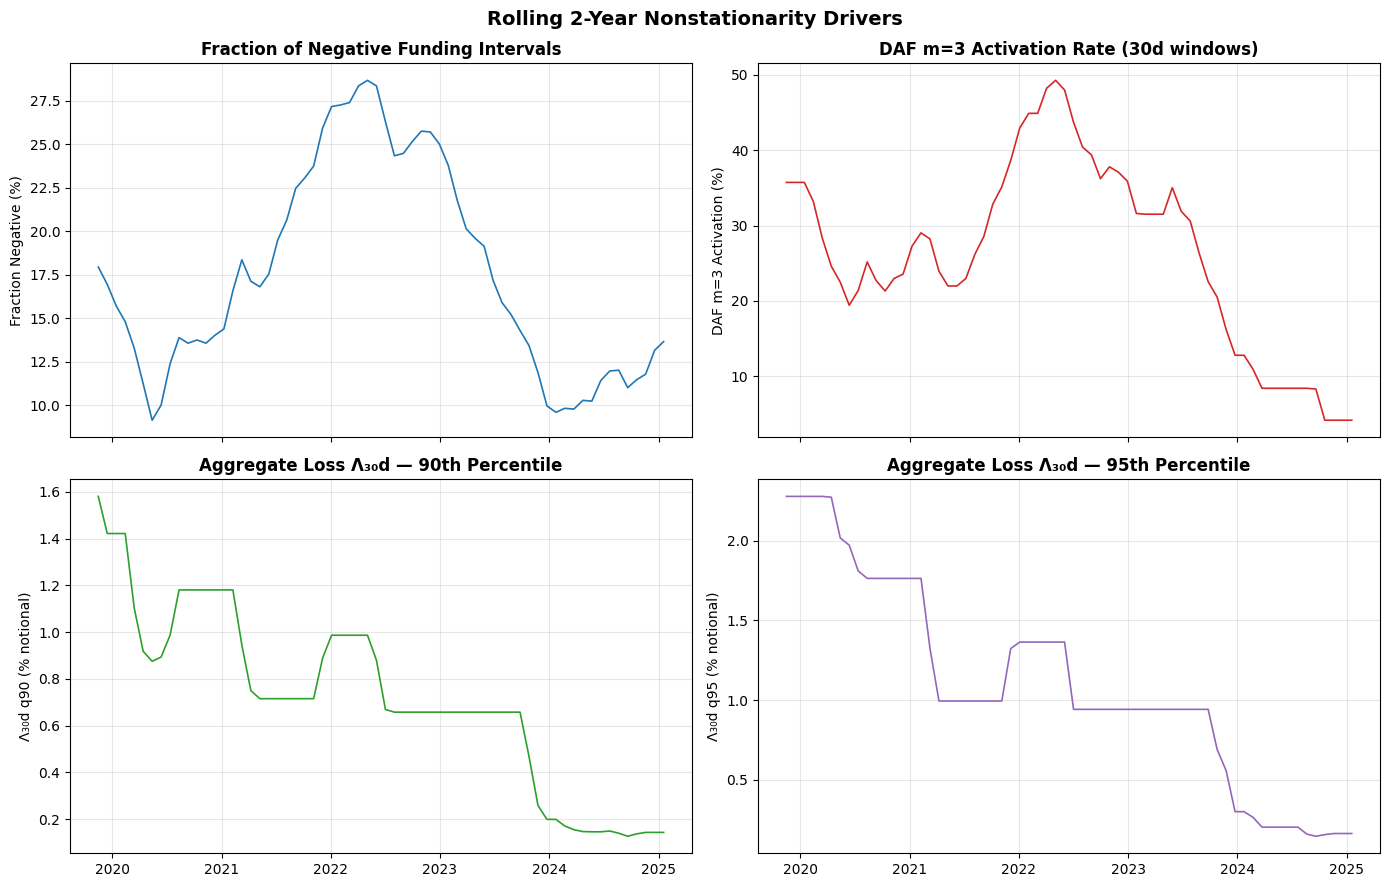

DAF activation range: 4.2% – 49.3%
Λ q90 range: 0.127% – 1.581%
Frac negative range: 9.1% – 28.7%


In [3]:
# Rolling 2-year diagnostics of key hedge-value drivers
ROLL_WINDOW = 2 * 365 * 3  # 2 years in 8h intervals (approx 2190)
ROLL_STEP = 90  # ~monthly steps

roll_starts = list(range(0, n_total - ROLL_WINDOW - HORIZON_30D, ROLL_STEP))
roll_centers = []
roll_frac_neg = []
roll_daf_act = []
roll_lambda_q90 = []
roll_lambda_q95 = []

for s in roll_starts:
    sub_cf = funding_cf[s : s + ROLL_WINDOW]
    sub_reg = is_regular[s : s + ROLL_WINDOW]
    center_idx = s + ROLL_WINDOW // 2
    roll_centers.append(timestamps.iloc[min(center_idx, n_total - 1)])

    roll_frac_neg.append(float(np.mean(sub_cf < 0)))

    daf_info = daf_activation_analysis(sub_cf, sub_reg, HORIZON_30D, threshold_b=0.0001, streak_m=3)
    roll_daf_act.append(daf_info.get("frac_windows_activated", 0.0))

    lq = lambda_quantiles_per_horizon(sub_cf, sub_reg, HORIZON_30D, quantiles=[0.90, 0.95])
    roll_lambda_q90.append(lq["q90"])
    roll_lambda_q95.append(lq["q95"])

driver_df = pd.DataFrame({
    "center": roll_centers,
    "frac_neg": roll_frac_neg,
    "daf_activation": roll_daf_act,
    "lambda_q90": roll_lambda_q90,
    "lambda_q95": roll_lambda_q95,
})

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

axes[0,0].plot(driver_df["center"], driver_df["frac_neg"] * 100, linewidth=1.2, color="#1f77b4")
axes[0,0].set_ylabel("Fraction Negative (%)")
axes[0,0].set_title("Fraction of Negative Funding Intervals", fontweight="bold")
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(driver_df["center"], driver_df["daf_activation"] * 100, linewidth=1.2, color="#d62728")
axes[0,1].set_ylabel("DAF m=3 Activation (%)")
axes[0,1].set_title("DAF m=3 Activation Rate (30d windows)", fontweight="bold")
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(driver_df["center"], driver_df["lambda_q90"] * 100, linewidth=1.2, color="#2ca02c")
axes[1,0].set_ylabel("Λ₃₀d q90 (% notional)")
axes[1,0].set_title("Aggregate Loss Λ₃₀d — 90th Percentile", fontweight="bold")
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(driver_df["center"], driver_df["lambda_q95"] * 100, linewidth=1.2, color="#9467bd")
axes[1,1].set_ylabel("Λ₃₀d q95 (% notional)")
axes[1,1].set_title("Aggregate Loss Λ₃₀d — 95th Percentile", fontweight="bold")
axes[1,1].grid(True, alpha=0.3)

fig.suptitle("Rolling 2-Year Nonstationarity Drivers", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(str(REPO_ROOT / "reports" / "figures" / "rolling_drivers_2y.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

print(f"DAF activation range: {min(roll_daf_act)*100:.1f}% – {max(roll_daf_act)*100:.1f}%")
print(f"Λ q90 range: {min(roll_lambda_q90)*100:.3f}% – {max(roll_lambda_q90)*100:.3f}%")
print(f"Frac negative range: {min(roll_frac_neg)*100:.1f}% – {max(roll_frac_neg)*100:.1f}%")

## 4. Pricing Protocol

This section specifies exactly how premiums and uncertainty bands are computed throughout the notebook.

**Tri-band uncertainty:**

1. **Bootstrap band (sampling uncertainty):** Block bootstrap (block_size=90) of the full Bybit series. Each resample generates a new set of 30d windows from which payoffs and premiums are computed. 90% CI from 200 resamples.

2. **Era band (nonstationarity):** Premiums computed on rolling 3-year sub-windows of the Bybit series, stepped monthly. The min/max/IQR across sub-windows captures how much the risk environment has changed over time — this is the **dominant** uncertainty source (Section 3).

3. **Episode-model scenario band:** The Phase 6.4 semi-Markov simulator (calibrated on the full sample with $g=5$, $p_{\text{augment}}=0.02$) generates 200 synthetic paths. Payoffs and premiums are computed on simulated 30d windows. This band is labeled **"Episode-model scenario band (conditional on full-sample calibration)"** — it is a scenario generator, not a forward predictor (NB05c OOS evidence).

EVT parameter uncertainty ($\xi$ instability) is **not** propagated as a separate band; NB05c showed its premium impact is ~15%, an order of magnitude smaller than era dispersion. We fix $\xi, \sigma$ at their point estimates.

**Premium method:** Full premium = Pure + CVaR risk load ($\lambda=0.35$, $\alpha=0.01$) + capital charge ($k_{\text{CoC}}=12\%$). Alternative functionals (Wang, Esscher) are explored in the Sensitivity section.

In [4]:
# Pre-compute the building blocks that all subsequent sections reuse
# 1. Full-sample 30d rolling windows
windows_30d, win_starts_30d = rolling_windows_regular(funding_cf, is_regular, HORIZON_30D)
n_windows = len(windows_30d)
print(f"30d rolling windows: {n_windows}")

# 2. Payoff arrays for each option strategy (full sample, h=1)
payoff_arrays = {}
payoff_arrays["Floor d=0.0001"] = np.array([vanilla_floor(w, deductible=0.0001) for w in windows_30d])
payoff_arrays["Floor d=0.0003"] = np.array([vanilla_floor(w, deductible=0.0003) for w in windows_30d])
payoff_arrays["DAF m=3"] = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=3, deductible=0.0001) for w in windows_30d])
payoff_arrays["DAF m=2"] = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=2, deductible=0.0001) for w in windows_30d])
payoff_arrays["ASL q90"] = np.array([aggregate_stop_loss(w, deductible_D=ASL_D_30D_Q90) for w in windows_30d])
payoff_arrays["ASL q95"] = np.array([aggregate_stop_loss(w, deductible_D=ASL_D_30D_Q95) for w in windows_30d])

# 3. Unhedged loss per window (Lambda)
lambda_per_window = np.array([total_loss(w) for w in windows_30d])

# 4. Unhedged net CF per window
netcf_per_window = np.array([float(np.sum(w)) for w in windows_30d])

# 5. Premiums for each option strategy (full premium)
premiums = {}
premium_details = {}
for name, payoffs in payoff_arrays.items():
    det = full_premium(payoffs)
    premiums[name] = det["total"]
    premium_details[name] = det

# 6. Swap rates (full-sample trailing estimate at the end of data)
swap_ewma_rate = estimate_swap_rate(funding_cf, SWAP_LOOKBACK, n_total, method="ewma", halflife=SWAP_HALFLIFE)
swap_mean_rate = estimate_swap_rate(funding_cf, SWAP_LOOKBACK, n_total, method="mean")

# 7. R_alpha for unhedged
R_unhedged = reserve_requirement(lambda_per_window, alpha=ALPHA)

print("\nPremiums (% of notional):")
for name, p in premiums.items():
    print(f"  {name}: {p*100:.4f}%")
print(f"\nSwap EWMA rate: {swap_ewma_rate:.8f} per 8h = {swap_ewma_rate * INTERVALS_PER_YEAR * 100:.2f}% APR")
print(f"Swap mean rate: {swap_mean_rate:.8f} per 8h = {swap_mean_rate * INTERVALS_PER_YEAR * 100:.2f}% APR")
print(f"\nR_alpha (unhedged CVaR 1%): {R_unhedged*100:.4f}% of notional")

30d rolling windows: 7634



Premiums (% of notional):
  Floor d=0.0001: 1.3110%
  Floor d=0.0003: 1.0482%
  DAF m=3: 0.8641%
  DAF m=2: 1.0095%
  ASL q90: 1.1024%
  ASL q95: 0.9061%

Swap EWMA rate: -0.00000277 per 8h = -0.30% APR
Swap mean rate: 0.00000316 per 8h = 0.35% APR

R_alpha (unhedged CVaR 1%): 3.7449% of notional


## 5. Flagship 30d Hedge-Efficiency Frontier: Reserve-Draw (Loss-Only) Lens

This is the first "money plot." For each strategy, we sweep the hedge ratio $h$ from 0 (unhedged) to 1 (fully hedged) and compute:

- **x-axis:** Risk = $\text{CVaR}_{1\%}$ of the hedged reserve draw (higher = worse).
- **y-axis:** Cost = Premium paid (% of notional).

Each strategy traces a curve: at $h=0$ all strategies collapse to the unhedged point; as $h$ increases, risk decreases (the hedge kicks in) but cost increases (you pay more premium). The **efficient strategies** are those whose curves are closest to the bottom-left corner (low cost, low risk).

The table shows detailed metrics at $h=1.0$ and $h=0.5$ including the capital efficiency metrics $\text{Eff}_A$ and $\text{Cost}_B$.

In [5]:
# Compute the loss-only frontier for each strategy across h-grid
def compute_loss_frontier(name, payoffs, premium, h_grid, lambda_arr, R_unhedged, alpha=0.01):
    rows = []
    for h in h_grid:
        hedged_losses = np.maximum(0.0, lambda_arr - h * payoffs) + h * premium
        r_h = reserve_requirement(hedged_losses, alpha=alpha)
        eff_a = efficiency_A(R_unhedged, r_h, h * premium) if h > 0 else 0.0
        cost_10 = total_economic_cost(h * premium, r_h, k=0.10, horizon_days=30)
        cost_20 = total_economic_cost(h * premium, r_h, k=0.20, horizon_days=30)
        rows.append({
            "strategy": name, "h": h,
            "premium": h * premium,
            "cvar_01_loss": r_h,
            "reserve_reduction": R_unhedged - r_h,
            "eff_A": eff_a,
            "cost_k10": cost_10, "cost_k20": cost_20,
            "mean_loss": float(np.mean(hedged_losses)),
        })
    return rows

frontier_rows = []

# Unhedged baseline
for h in H_GRID:
    frontier_rows.append({
        "strategy": "Unhedged", "h": h,
        "premium": 0.0,
        "cvar_01_loss": R_unhedged,
        "reserve_reduction": 0.0, "eff_A": 0.0,
        "cost_k10": total_economic_cost(0, R_unhedged, 0.10, 30),
        "cost_k20": total_economic_cost(0, R_unhedged, 0.20, 30),
        "mean_loss": float(np.mean(lambda_per_window)),
    })

# Swap strategies
for swap_name, swap_rate in [("Swap (EWMA)", swap_ewma_rate), ("Swap (mean)", swap_mean_rate)]:
    for h in H_GRID:
        swap_net_per_win = np.array([float(len(w)) * swap_rate for w in windows_30d])
        blended_loss = np.maximum(0.0, (1 - h) * lambda_per_window + h * np.maximum(0.0, -swap_net_per_win))
        r_h = reserve_requirement(blended_loss, alpha=ALPHA)
        cost_10 = total_economic_cost(0, r_h, 0.10, 30)
        cost_20 = total_economic_cost(0, r_h, 0.20, 30)
        frontier_rows.append({
            "strategy": swap_name, "h": h,
            "premium": 0.0,
            "cvar_01_loss": r_h,
            "reserve_reduction": R_unhedged - r_h,
            "eff_A": 0.0,
            "cost_k10": cost_10, "cost_k20": cost_20,
            "mean_loss": float(np.mean(blended_loss)),
        })

# Option strategies
for name in ["Floor d=0.0001", "Floor d=0.0003", "DAF m=3", "DAF m=2", "ASL q90", "ASL q95"]:
    frontier_rows.extend(
        compute_loss_frontier(name, payoff_arrays[name], premiums[name],
                              H_GRID, lambda_per_window, R_unhedged, ALPHA)
    )

frontier_df = pd.DataFrame(frontier_rows)
print(f"Frontier computed: {len(frontier_df)} rows ({len(frontier_df['strategy'].unique())} strategies x {len(H_GRID)} h-values)")

Frontier computed: 99 rows (9 strategies x 11 h-values)


### Frontier plot (loss-only lens)

Each curve traces a strategy's cost-vs-risk trade-off as the hedge ratio $h$ increases from 0 to 1. Strategies closer to the bottom-left corner are more efficient.

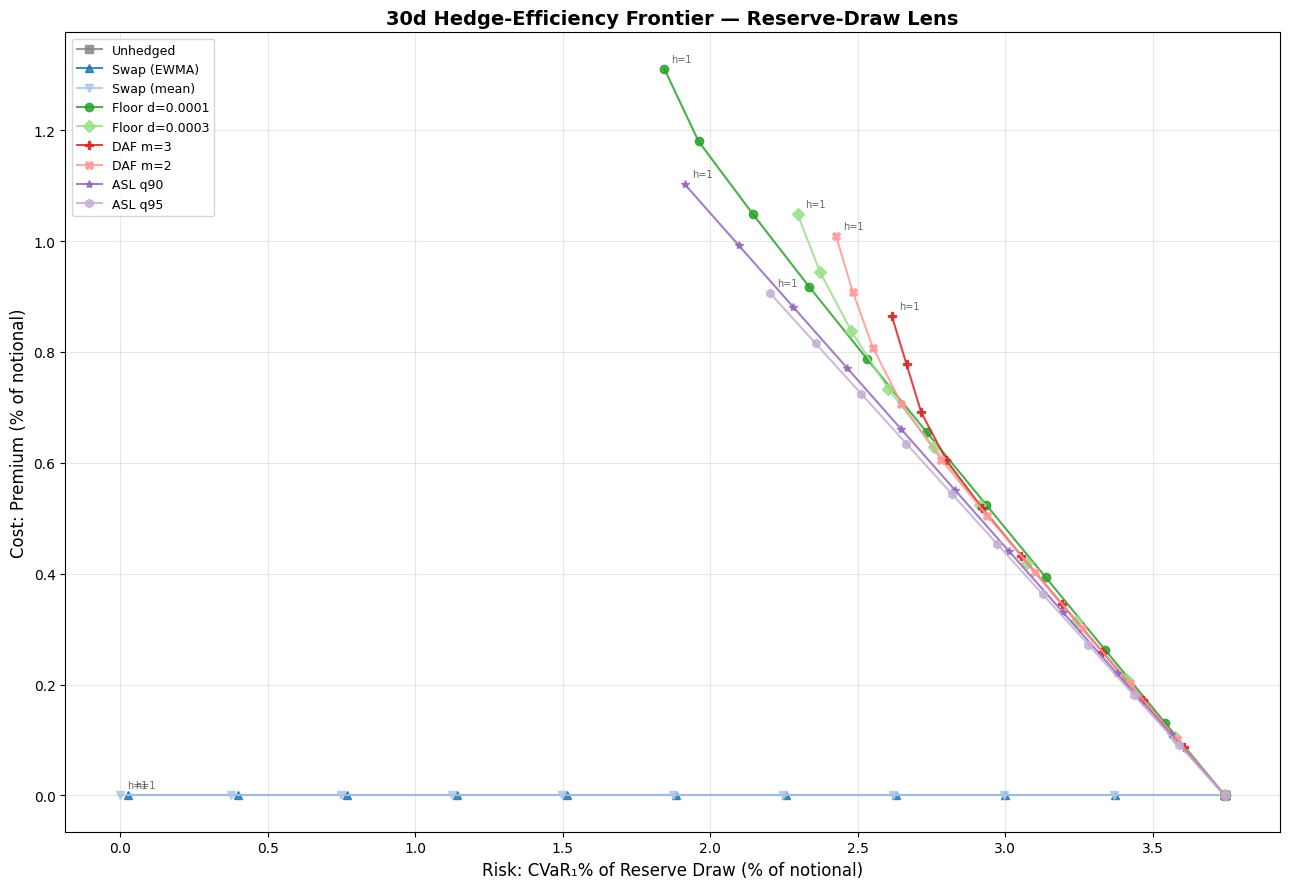

In [6]:
fig, ax = plt.subplots(figsize=(13, 9))

COLORS = {
    "Unhedged": "#888888", "Swap (EWMA)": "#1f77b4", "Swap (mean)": "#aec7e8",
    "Floor d=0.0001": "#2ca02c", "Floor d=0.0003": "#98df8a",
    "DAF m=3": "#d62728", "DAF m=2": "#ff9896",
    "ASL q90": "#9467bd", "ASL q95": "#c5b0d5",
}
MARKERS = {
    "Unhedged": "s", "Swap (EWMA)": "^", "Swap (mean)": "v",
    "Floor d=0.0001": "o", "Floor d=0.0003": "D",
    "DAF m=3": "P", "DAF m=2": "X", "ASL q90": "*", "ASL q95": "h",
}

for strat in frontier_df["strategy"].unique():
    sdf = frontier_df[frontier_df["strategy"] == strat].sort_values("h")
    ax.plot(sdf["cvar_01_loss"] * 100, sdf["premium"] * 100,
            marker=MARKERS.get(strat, "o"), label=strat, color=COLORS.get(strat, "#333"),
            linewidth=1.5, markersize=6, alpha=0.85)
    h1 = sdf[sdf["h"] == 1.0]
    if len(h1) > 0 and strat != "Unhedged":
        ax.annotate(f"h=1", (h1["cvar_01_loss"].values[0]*100, h1["premium"].values[0]*100),
                    fontsize=7, alpha=0.6, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Risk: CVaR₁% of Reserve Draw (% of notional)", fontsize=12)
ax.set_ylabel("Cost: Premium (% of notional)", fontsize=12)
ax.set_title("30d Hedge-Efficiency Frontier — Reserve-Draw Lens", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(REPO_ROOT / "reports/figures/frontier_30d_loss_only.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

### Frontier table at $h = 1.0$ and $h = 0.5$

This table compares all strategies at full hedge ($h=1$) and half hedge ($h=0.5$), showing premiums, risk metrics, capital efficiency, and total economic cost under two cost-of-capital assumptions.

In [7]:
# Table at h=1.0 and h=0.5
summary_h = frontier_df[frontier_df["h"].isin([0.5, 1.0])].copy()
summary_h["premium_pct"] = summary_h["premium"] * 100
summary_h["cvar_pct"] = summary_h["cvar_01_loss"] * 100
summary_h["reduction_pct"] = summary_h["reserve_reduction"] * 100
summary_h["cost_k10_pct"] = summary_h["cost_k10"] * 100
summary_h["cost_k20_pct"] = summary_h["cost_k20"] * 100
summary_h["eff_A_disp"] = summary_h["eff_A"].round(2)

display_cols = ["strategy", "h", "premium_pct", "cvar_pct", "reduction_pct", "eff_A_disp", "cost_k10_pct", "cost_k20_pct"]
display_names = {"strategy": "Strategy", "h": "h", "premium_pct": "Premium (%)", "cvar_pct": "CVaR₁% (%)",
                 "reduction_pct": "Reserve Reduction (%)", "eff_A_disp": "Eff_A",
                 "cost_k10_pct": "Cost (k=10%)", "cost_k20_pct": "Cost (k=20%)"}

tbl = summary_h[display_cols].rename(columns=display_names).sort_values(["h", "Strategy"])
print(tbl.to_string(index=False, float_format="%.4f"))

frontier_df.to_csv(str(REPO_ROOT / "reports/tables/frontier_30d.csv"), index=False)
print("\nSaved: reports/tables/frontier_30d.csv")

      Strategy      h  Premium (%)  CVaR₁% (%)  Reserve Reduction (%)  Eff_A  Cost (k=10%)  Cost (k=20%)
       ASL q90 0.5000       0.5512      2.8293                 0.9156 1.6600        0.5744        0.5977
       ASL q95 0.5000       0.4531      2.9739                 0.7710 1.7000        0.4775        0.5019
       DAF m=2 0.5000       0.5048      2.9390                 0.8059 1.6000        0.5289        0.5531
       DAF m=3 0.5000       0.4321      3.0551                 0.6898 1.6000        0.4572        0.4823
Floor d=0.0001 0.5000       0.6555      2.7336                 1.0114 1.5400        0.6780        0.7005
Floor d=0.0003 0.5000       0.5241      2.9134                 0.8315 1.5900        0.5481        0.5720
   Swap (EWMA) 0.5000       0.0000      1.8849                 1.8600 0.0000        0.0155        0.0310
   Swap (mean) 0.5000       0.0000      1.8725                 1.8725 0.0000        0.0154        0.0308
      Unhedged 0.5000       0.0000      3.7449         

## 6. Flagship 30d Frontier: Net Cashflow (Carry) Lens

The net-CF lens answers: *does hedging destroy carry?* For each window, the hedged net cashflow is:

$$\text{NetCF}(H, h) = \sum f_i + h \cdot \text{Payoff}(H) - h \cdot \text{Premium}(H)$$

The trade-off is: options reduce downside (improving left-tail CVaR) but cost premium (reducing mean CF). Swaps eliminate variability entirely but lock in a fixed rate that may sacrifice upside.

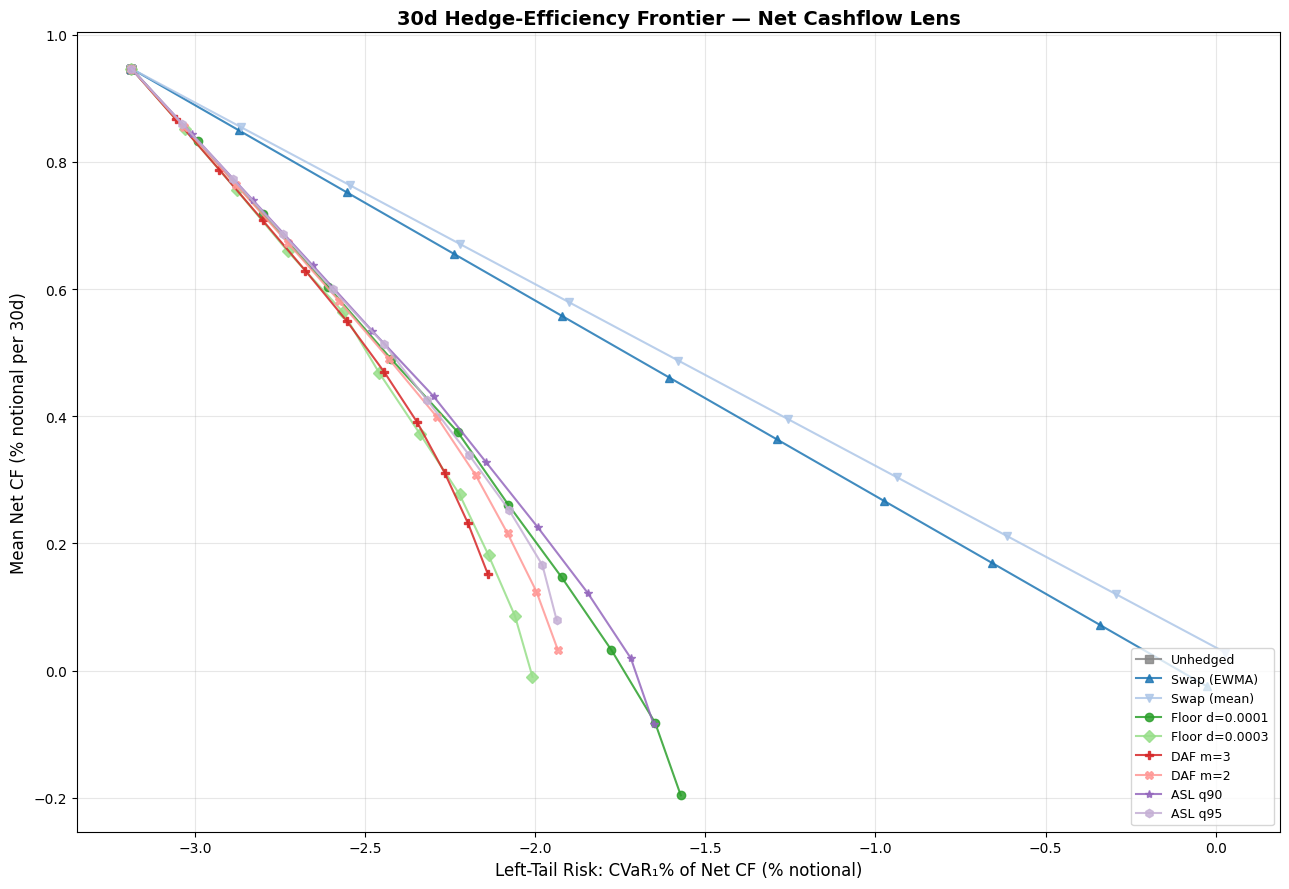

Upside retention at h=1 (Mean Net CF as % of unhedged):
  Unhedged            : 100.0%  (Mean NetCF: 0.9468%)
  DAF m=3             : 16.1%  (Mean NetCF: 0.1522%)
  ASL q95             : 8.4%  (Mean NetCF: 0.0793%)
  DAF m=2             : 3.5%  (Mean NetCF: 0.0331%)
  Swap (mean)         : 3.0%  (Mean NetCF: 0.0285%)
  Floor d=0.0003      : -1.0%  (Mean NetCF: -0.0096%)
  Swap (EWMA)         : -2.6%  (Mean NetCF: -0.0249%)
  ASL q90             : -8.8%  (Mean NetCF: -0.0837%)
  Floor d=0.0001      : -20.7%  (Mean NetCF: -0.1962%)


In [8]:
# Net-CF frontier
netcf_rows = []

# Unhedged
for h in H_GRID:
    cvar_nc = cvar(netcf_per_window, ALPHA)
    netcf_rows.append({
        "strategy": "Unhedged", "h": h,
        "mean_netcf": float(np.mean(netcf_per_window)),
        "cvar_01_netcf": cvar_nc,
        "p_loss": prob_loss(netcf_per_window),
        "premium": 0.0,
    })

# Swaps
for swap_name, swap_rate in [("Swap (EWMA)", swap_ewma_rate), ("Swap (mean)", swap_mean_rate)]:
    for h in H_GRID:
        swap_cf = np.array([float(len(w)) * swap_rate for w in windows_30d])
        blended_cf = (1 - h) * netcf_per_window + h * swap_cf
        netcf_rows.append({
            "strategy": swap_name, "h": h,
            "mean_netcf": float(np.mean(blended_cf)),
            "cvar_01_netcf": cvar(blended_cf, ALPHA),
            "p_loss": prob_loss(blended_cf),
            "premium": 0.0,
        })

# Options
for name in ["Floor d=0.0001", "Floor d=0.0003", "DAF m=3", "DAF m=2", "ASL q90", "ASL q95"]:
    p = premiums[name]
    for h in H_GRID:
        hedged_cf = netcf_per_window + h * payoff_arrays[name] - h * p
        netcf_rows.append({
            "strategy": name, "h": h,
            "mean_netcf": float(np.mean(hedged_cf)),
            "cvar_01_netcf": cvar(hedged_cf, ALPHA),
            "p_loss": prob_loss(hedged_cf),
            "premium": h * p,
        })

netcf_df = pd.DataFrame(netcf_rows)

fig, ax = plt.subplots(figsize=(13, 9))
for strat in netcf_df["strategy"].unique():
    sdf = netcf_df[netcf_df["strategy"] == strat].sort_values("h")
    ax.plot(sdf["cvar_01_netcf"] * 100, sdf["mean_netcf"] * 100,
            marker=MARKERS.get(strat, "o"), label=strat, color=COLORS.get(strat, "#333"),
            linewidth=1.5, markersize=6, alpha=0.85)

ax.set_xlabel("Left-Tail Risk: CVaR₁% of Net CF (% notional)", fontsize=12)
ax.set_ylabel("Mean Net CF (% notional per 30d)", fontsize=12)
ax.set_title("30d Hedge-Efficiency Frontier — Net Cashflow Lens", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(REPO_ROOT / "reports/figures/frontier_30d_netcf.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

# Upside retention table at h=1
h1_nc = netcf_df[netcf_df["h"] == 1.0].copy()
unhedged_mean = h1_nc[h1_nc["strategy"] == "Unhedged"]["mean_netcf"].values[0]
h1_nc["upside_retention"] = h1_nc["mean_netcf"] / unhedged_mean * 100
print("Upside retention at h=1 (Mean Net CF as % of unhedged):")
for _, row in h1_nc.sort_values("mean_netcf", ascending=False).iterrows():
    print(f"  {row['strategy']:20s}: {row['upside_retention']:.1f}%  (Mean NetCF: {row['mean_netcf']*100:.4f}%)")

## 7. Dominance Under Uncertainty

Given the wide uncertainty bands documented in NB05c, we need a disciplined rule for when one strategy can be claimed to dominate another.

**Formal dominance rule:** Strategy $A$ **dominates** strategy $B$ under the loss-only lens if, for all $h \in \{0.1, 0.2, \ldots, 1.0\}$, $A$'s $\text{CVaR}_{1\%}$ of reserve draw is lower than $B$'s at the same premium cost (or lower premium at the same risk), across the full-sample point estimates.

Strategies that do not satisfy this condition are labeled **"overlapping / statistically indistinguishable"** at the given confidence level.

This point-estimate dominance check is the baseline. In Section 10, we verify whether these relationships hold under alternative pricing functionals and training windows — only relationships that survive all checks earn Tier 1 status in the conclusions.

In [9]:
# Point-estimate dominance check (loss-only lens at h=1)
h1_loss = frontier_df[frontier_df["h"] == 1.0].set_index("strategy")

print("=== Dominance Analysis (Loss-Only Lens, h=1.0) ===\n")
print(f"{'Strategy':20s} {'Premium (%)':>12s} {'CVaR₁% (%)':>12s} {'Eff_A':>8s}")
print("-" * 56)

for strat in h1_loss.index:
    row = h1_loss.loc[strat]
    print(f"{strat:20s} {row['premium']*100:12.4f} {row['cvar_01_loss']*100:12.4f} {row['eff_A']:8.2f}")

# Sharpness (reserve-draw reduction per unit premium)
print("\n=== Sharpness = ΔCVaR / Premium (higher = more efficient) ===\n")
option_strats = [s for s in h1_loss.index if s not in ("Unhedged", "Swap (EWMA)", "Swap (mean)")]
for strat in option_strats:
    row = h1_loss.loc[strat]
    if row["premium"] > 0:
        sharpness = (R_unhedged - row["cvar_01_loss"]) / row["premium"]
        print(f"  {strat:20s}: {sharpness:.2f}")

# Pairwise dominance
print("\n=== Pairwise Dominance (option products, h=1) ===")
print("A dominates B if: lower CVaR at equal or lower premium.\n")
for a in option_strats:
    for b in option_strats:
        if a == b:
            continue
        ra = h1_loss.loc[a]
        rb = h1_loss.loc[b]
        if ra["cvar_01_loss"] <= rb["cvar_01_loss"] and ra["premium"] <= rb["premium"]:
            if ra["cvar_01_loss"] < rb["cvar_01_loss"] or ra["premium"] < rb["premium"]:
                print(f"  {a} dominates {b}")

=== Dominance Analysis (Loss-Only Lens, h=1.0) ===

Strategy              Premium (%)   CVaR₁% (%)    Eff_A
--------------------------------------------------------
Unhedged                   0.0000       3.7449     0.00
Swap (EWMA)                0.0000       0.0249     0.00
Swap (mean)                0.0000       0.0000     0.00
Floor d=0.0001             1.3110       1.8442     1.45
Floor d=0.0003             1.0482       2.2965     1.38
DAF m=3                    0.8641       2.6161     1.31
DAF m=2                    1.0095       2.4260     1.31
ASL q90                    1.1024       1.9138     1.66
ASL q95                    0.9061       2.2028     1.70

=== Sharpness = ΔCVaR / Premium (higher = more efficient) ===

  Floor d=0.0001      : 1.45
  Floor d=0.0003      : 1.38
  DAF m=3             : 1.31
  DAF m=2             : 1.31
  ASL q90             : 1.66
  ASL q95             : 1.70

=== Pairwise Dominance (option products, h=1) ===
A dominates B if: lower CVaR at equal or l

## 8. Walk-Forward Evaluation (Deployment Realism)

The walk-forward protocol is the **deployment-realistic answer** to the nonstationarity problem identified in NB05c. Rather than evaluating on the same data used to price (which would be lookahead bias), we:

1. At each evaluation month $t$, take the trailing $W = 3$ years of data.
2. Price each strategy using **only** the trailing window — no future data.
3. Apply the hedge to the **next 30 days** of realized funding.
4. Record the realized reserve draw, premium paid, and net CF.

This produces an out-of-sample time series showing what would have happened if a protocol deployed each hedge month-by-month. The walk-forward starts from ~2022-10 (after 3 years of training data become available) and runs through the end of the series.

For swaps, the fixed rate is the EWMA/mean of the trailing window. For options, the premium is computed from the trailing window's rolling 30d payoff history.

In [10]:
from ddx.backtest.walkforward import walkforward_evaluate

# Define strategies for walk-forward
wf_strategies = [
    {"name": "Unhedged", "type": "unhedged"},
    {"name": "Swap (EWMA)", "type": "swap", "swap_method": "ewma", "swap_lookback": 90, "swap_halflife": 45},
    {"name": "Swap (mean)", "type": "swap", "swap_method": "mean", "swap_lookback": 90},
    {"name": "Floor d=0.0001", "type": "option",
     "payoff_fn": vanilla_floor, "payoff_kwargs": {"deductible": 0.0001}},
    {"name": "Floor d=0.0003", "type": "option",
     "payoff_fn": vanilla_floor, "payoff_kwargs": {"deductible": 0.0003}},
    {"name": "DAF m=3", "type": "option",
     "payoff_fn": distress_activated_floor,
     "payoff_kwargs": {"threshold_b": 0.0001, "streak_m": 3, "deductible": 0.0001}},
    {"name": "DAF m=2", "type": "option",
     "payoff_fn": distress_activated_floor,
     "payoff_kwargs": {"threshold_b": 0.0001, "streak_m": 2, "deductible": 0.0001}},
    {"name": "ASL q90", "type": "option",
     "payoff_fn": aggregate_stop_loss,
     "payoff_kwargs": {"deductible_D": "calibrate"},
     "asl_quantile": 0.90},
]

print("Running walk-forward (W=3 years, step=30d)...")
wf_df = walkforward_evaluate(
    funding_cf, is_regular, wf_strategies,
    horizon_intervals=HORIZON_30D,
    train_years=3.0,
    step_intervals=HORIZON_30D,
    rng=np.random.default_rng(42),
)
print(f"Walk-forward complete: {len(wf_df)} records, {wf_df['month_idx'].nunique()} months")
wf_df.to_csv(str(REPO_ROOT / "reports/tables/walkforward_pnl.csv"), index=False)
print("Saved: reports/tables/walkforward_pnl.csv")

Running walk-forward (W=3 years, step=30d)...


Walk-forward complete: 416 records, 52 months
Saved: reports/tables/walkforward_pnl.csv


### Walk-forward results: realized reserve draw

The time series below shows realized reserve draw per month for the unhedged position and the top strategies. Months where a hedge significantly reduced the draw demonstrate deployment value; months where the hedge added cost without benefit (calm periods) show the insurance cost.

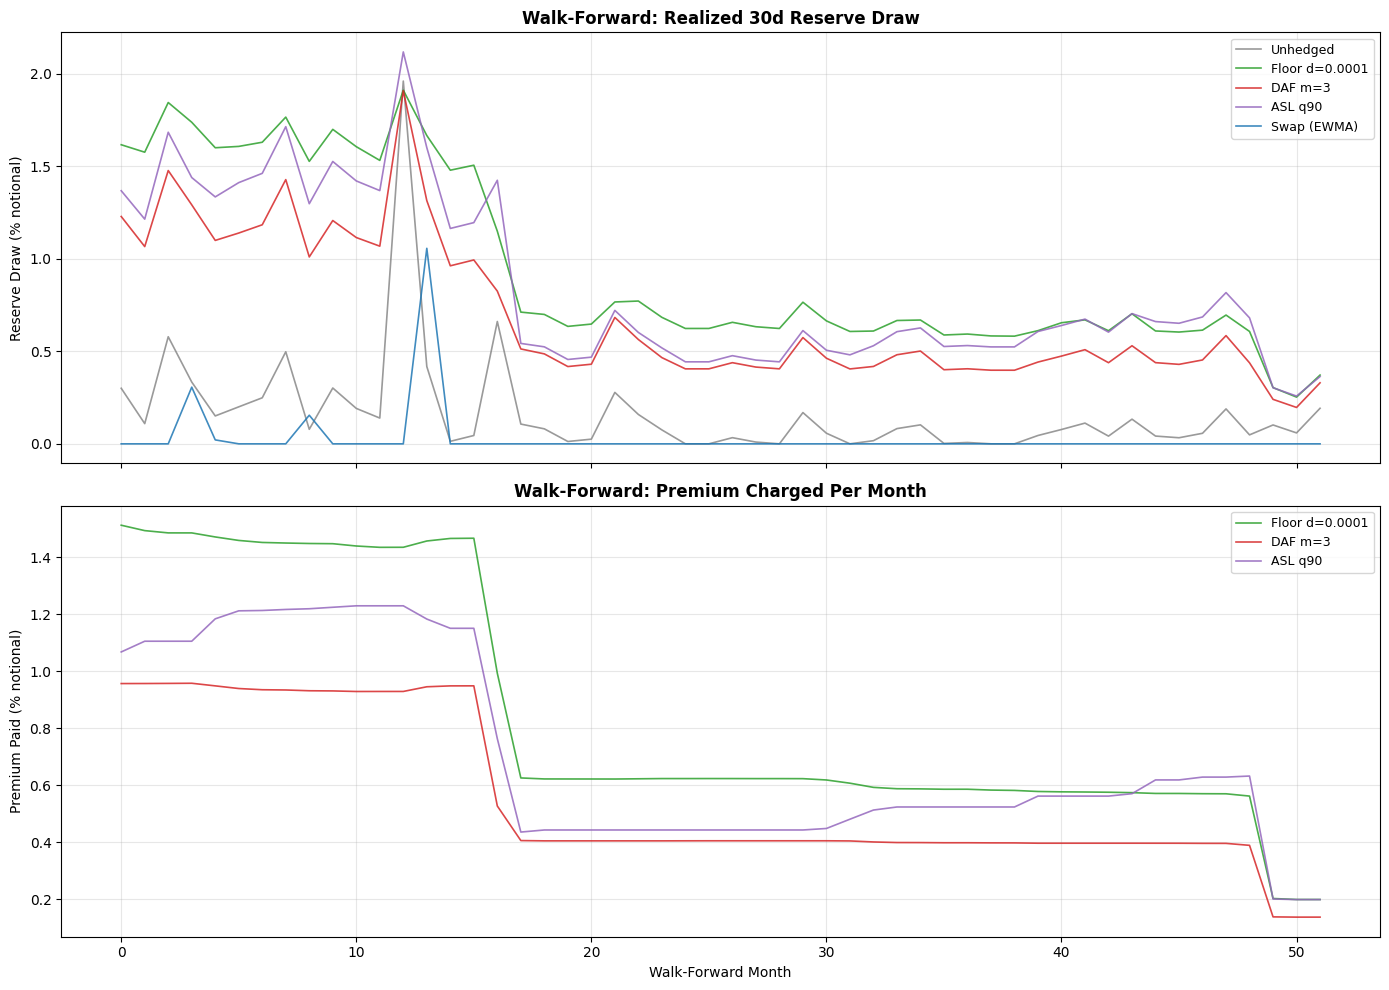


=== Walk-Forward Summary (mean over all months) ===

                mean_draw_pct  max_draw_pct  mean_premium_pct
strategy                                                     
ASL q90                0.8457        2.1192            0.7018
DAF m=2                0.8101        1.8637            0.6833
DAF m=3                0.6907        1.9092            0.5551
Floor d=0.0001         0.9461        1.9123            0.8495
Floor d=0.0003         0.7026        2.2733            0.5655
Swap (EWMA)            0.0296        1.0572            0.0000
Swap (mean)            0.0425        1.6269            0.0000
Unhedged               0.1651        1.9617            0.0000


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1: Reserve draw
ax = axes[0]
for strat in ["Unhedged", "Floor d=0.0001", "DAF m=3", "ASL q90", "Swap (EWMA)"]:
    sdf = wf_df[wf_df["strategy"] == strat].sort_values("month_idx")
    if len(sdf) == 0:
        continue
    ax.plot(sdf["month_idx"], sdf["reserve_draw_hedged"] * 100,
            label=strat, color=COLORS.get(strat, "#333"), linewidth=1.2, alpha=0.85)
ax.set_ylabel("Reserve Draw (% notional)")
ax.set_title("Walk-Forward: Realized 30d Reserve Draw", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Premium paid
ax = axes[1]
for strat in ["Floor d=0.0001", "DAF m=3", "ASL q90"]:
    sdf = wf_df[wf_df["strategy"] == strat].sort_values("month_idx")
    if len(sdf) == 0:
        continue
    ax.plot(sdf["month_idx"], sdf["premium"] * 100,
            label=strat, color=COLORS.get(strat, "#333"), linewidth=1.2, alpha=0.85)
ax.set_ylabel("Premium Paid (% notional)")
ax.set_xlabel("Walk-Forward Month")
ax.set_title("Walk-Forward: Premium Charged Per Month", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(str(REPO_ROOT / "reports/figures/walkforward_reserve_draw.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

# Summary stats
print("\n=== Walk-Forward Summary (mean over all months) ===\n")
wf_summary = wf_df.groupby("strategy").agg(
    mean_draw=("reserve_draw_hedged", "mean"),
    max_draw=("reserve_draw_hedged", "max"),
    mean_premium=("premium", "mean"),
    mean_netcf=("net_cf", "mean"),
).round(6)
wf_summary["mean_draw_pct"] = wf_summary["mean_draw"] * 100
wf_summary["max_draw_pct"] = wf_summary["max_draw"] * 100
wf_summary["mean_premium_pct"] = wf_summary["mean_premium"] * 100
print(wf_summary[["mean_draw_pct", "max_draw_pct", "mean_premium_pct"]].to_string())

## 9. Reserve vs Hedge: Capital Efficiency

This section answers the practical treasury question: **should I hold reserves or buy insurance?**

For a protocol like Ethena, holding reserves has an opportunity cost — capital locked in a reserve fund earns nothing (or earns a reduced rate). If the cost-of-capital is $k$, then holding reserve $R$ costs $k \cdot (T/365) \cdot R$ per period.

Insurance (options) have an explicit premium but reduce the required reserve. The total economic cost is:
$$\text{Cost}(H) = \text{Premium}(H) + k \cdot \frac{T}{365} \cdot R_\alpha(H)$$

A hedge is capital-efficient if its total cost is lower than holding reserves alone.

**Swap margin proxy:** Swaps have zero premium but require margin/collateral. We estimate the required margin as $M_\alpha = \text{CVaR}_\alpha(\max(0, -X^{\text{swap}}))$ — the tail loss from the swap itself. This prevents the "swaps are free" assumption.

In [12]:
# Capital efficiency comparison at h=1
print("=== Capital Efficiency Comparison (30d, h=1.0) ===\n")

# Swap margin
swap_ewma_net_cfs = np.array([float(len(w)) * swap_ewma_rate for w in windows_30d])
swap_mean_net_cfs = np.array([float(len(w)) * swap_mean_rate for w in windows_30d])

M_swap_ewma = swap_margin_proxy(swap_ewma_net_cfs, alpha=ALPHA)
M_swap_mean = swap_margin_proxy(swap_mean_net_cfs, alpha=ALPHA)

cap_rows = []

# Unhedged
cap_rows.append({
    "Strategy": "Unhedged", "Premium (%)": 0.0,
    "Reserve R_α (%)": R_unhedged * 100, "Margin M_α (%)": 0.0,
    "Cost(k=10%) (%)": total_economic_cost(0, R_unhedged, 0.10, 30) * 100,
    "Cost(k=20%) (%)": total_economic_cost(0, R_unhedged, 0.20, 30) * 100,
})

# Swaps (with margin)
for sn, sr, margin in [("Swap (EWMA)", swap_ewma_rate, M_swap_ewma), ("Swap (mean)", swap_mean_rate, M_swap_mean)]:
    swap_losses = np.maximum(0.0, -np.array([float(len(w)) * sr for w in windows_30d]))
    r_swap = reserve_requirement(swap_losses, alpha=ALPHA) if np.any(swap_losses > 0) else 0.0
    cap_rows.append({
        "Strategy": sn, "Premium (%)": 0.0,
        "Reserve R_α (%)": r_swap * 100, "Margin M_α (%)": margin * 100,
        "Cost(k=10%) (%)": total_economic_cost(0, r_swap + margin, 0.10, 30) * 100,
        "Cost(k=20%) (%)": total_economic_cost(0, r_swap + margin, 0.20, 30) * 100,
    })

# Options at h=1
for name in ["Floor d=0.0001", "Floor d=0.0003", "DAF m=3", "DAF m=2", "ASL q90", "ASL q95"]:
    row_h1 = frontier_df[(frontier_df["strategy"] == name) & (frontier_df["h"] == 1.0)].iloc[0]
    cap_rows.append({
        "Strategy": name, "Premium (%)": row_h1["premium"] * 100,
        "Reserve R_α (%)": row_h1["cvar_01_loss"] * 100, "Margin M_α (%)": 0.0,
        "Cost(k=10%) (%)": row_h1["cost_k10"] * 100,
        "Cost(k=20%) (%)": row_h1["cost_k20"] * 100,
    })

cap_df = pd.DataFrame(cap_rows)
print(cap_df.to_string(index=False, float_format="%.4f"))
cap_df.to_csv(str(REPO_ROOT / "reports/tables/capital_efficiency_30d.csv"), index=False)
print("\nSaved: reports/tables/capital_efficiency_30d.csv")

=== Capital Efficiency Comparison (30d, h=1.0) ===

      Strategy  Premium (%)  Reserve R_α (%)  Margin M_α (%)  Cost(k=10%) (%)  Cost(k=20%) (%)
      Unhedged       0.0000           3.7449          0.0000           0.0308           0.0616
   Swap (EWMA)       0.0000           0.0249          0.0249           0.0004           0.0008
   Swap (mean)       0.0000           0.0000          0.0000           0.0000           0.0000
Floor d=0.0001       1.3110           1.8442          0.0000           1.3262           1.3414
Floor d=0.0003       1.0482           2.2965          0.0000           1.0671           1.0860
       DAF m=3       0.8641           2.6161          0.0000           0.8856           0.9071
       DAF m=2       1.0095           2.4260          0.0000           1.0295           1.0494
       ASL q90       1.1024           1.9138          0.0000           1.1181           1.1338
       ASL q95       0.9061           2.2028          0.0000           0.9242           0.942

## 10. Sensitivities

Each sensitivity test gets one plot and one table, following the discipline of Pro Report 8. These checks verify whether the headline conclusions from Sections 5–7 are robust or fragile.

### 10a. Pricing Functional Sensitivity

We recompute premiums under four methods — Full (CVaR-loaded), Wang distortion ($\theta=0.5$), Esscher ($\theta=1.0$), and target Sharpe ($\text{SR}=0.75$) — and check whether product rankings change.

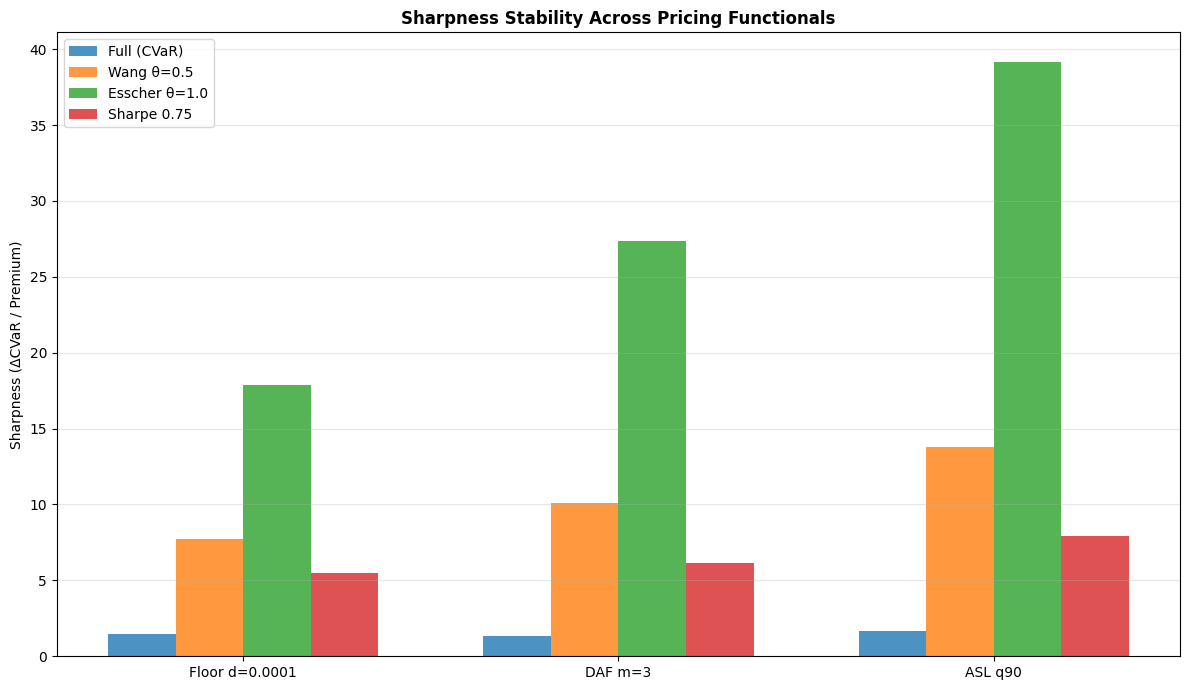

Method          Esscher θ=1.0  Full (CVaR)  Sharpe 0.75  Wang θ=0.5
Strategy                                                           
ASL q90                 39.15         1.66         7.93       13.81
ASL q95                 61.30         1.70         9.40       19.42
DAF m=2                 23.01         1.31         5.76        8.95
DAF m=3                 27.34         1.31         6.15       10.09
Floor d=0.0001          17.89         1.45         5.47        7.74
Floor d=0.0003          25.88         1.38         6.40       10.10


In [13]:
# Pricing functional sensitivity
methods = ["full", "wang", "esscher", "target_sharpe"]
method_labels = {"full": "Full (CVaR)", "wang": "Wang θ=0.5", "esscher": "Esscher θ=1.0", "target_sharpe": "Sharpe 0.75"}

func_rows = []
for name, payoffs in payoff_arrays.items():
    for m in methods:
        res = compute_premium(payoffs, method=m)
        prem = res.get("premium", res.get("total", 0.0))
        hedged_losses = np.maximum(0.0, lambda_per_window - payoffs) + prem
        r_h = reserve_requirement(hedged_losses, alpha=ALPHA)
        sharpness = (R_unhedged - r_h) / prem if prem > 0 else 0.0
        func_rows.append({
            "Strategy": name, "Method": method_labels[m],
            "Premium (%)": prem * 100, "CVaR₁% (%)": r_h * 100,
            "Sharpness": sharpness,
        })

func_df = pd.DataFrame(func_rows)

fig, ax = plt.subplots(figsize=(12, 7))
strategies_to_plot = ["Floor d=0.0001", "DAF m=3", "ASL q90"]
width = 0.18
x = np.arange(len(strategies_to_plot))
for i, m in enumerate(methods):
    vals = []
    for s in strategies_to_plot:
        row = func_df[(func_df["Strategy"] == s) & (func_df["Method"] == method_labels[m])]
        vals.append(row["Sharpness"].values[0] if len(row) > 0 else 0)
    ax.bar(x + i * width, vals, width, label=method_labels[m], alpha=0.8)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(strategies_to_plot)
ax.set_ylabel("Sharpness (ΔCVaR / Premium)")
ax.set_title("Sharpness Stability Across Pricing Functionals", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig(str(REPO_ROOT / "reports/figures/sharpness_30d.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

print(func_df.pivot_table(index="Strategy", columns="Method", values="Sharpness").round(2).to_string())

### 10b. Cost-of-Capital Sensitivity

The total economic cost $\text{Cost}(H) = \text{Premium} + k \cdot (T/365) \cdot R_\alpha(H)$ depends on $k$. At higher capital cost, holding reserves becomes more expensive, making insurance more attractive. This sensitivity sweeps $k \in \{10\%, 20\%, 30\%\}$.

In [14]:
# Cost-of-capital sensitivity
k_values = [0.10, 0.20, 0.30]
coc_rows = []

for name in ["Unhedged", "Floor d=0.0001", "DAF m=3", "ASL q90", "Swap (EWMA)"]:
    h1 = frontier_df[(frontier_df["strategy"] == name) & (frontier_df["h"] == 1.0)]
    if len(h1) == 0:
        continue
    row = h1.iloc[0]
    prem = row["premium"]
    r_h = row["cvar_01_loss"]
    for k in k_values:
        cost = total_economic_cost(prem, r_h, k, 30)
        coc_rows.append({"Strategy": name, "k": f"{k*100:.0f}%", "Total Cost (%)": cost * 100})

coc_df = pd.DataFrame(coc_rows)
print(coc_df.pivot_table(index="Strategy", columns="k", values="Total Cost (%)").round(4).to_string())

k                  10%     20%     30%
Strategy                              
ASL q90         1.1181  1.1338  1.1496
DAF m=3         0.8856  0.9071  0.9286
Floor d=0.0001  1.3262  1.3414  1.3565
Swap (EWMA)     0.0002  0.0004  0.0006
Unhedged        0.0308  0.0616  0.0923


### 10c. Swap Estimator Sensitivity

We compare the two swap rate estimators — EWMA (recency-weighted, adapts faster) vs trailing mean (equal-weighted, smoother). This checks whether the swap benchmark choice affects conclusions.

In [15]:
# Swap estimator comparison
swap_comp = frontier_df[
    (frontier_df["strategy"].isin(["Swap (EWMA)", "Swap (mean)"])) & (frontier_df["h"] == 1.0)
][["strategy", "cvar_01_loss", "mean_loss"]].copy()
swap_comp["cvar_pct"] = swap_comp["cvar_01_loss"] * 100
swap_comp["mean_loss_pct"] = swap_comp["mean_loss"] * 100
print("Swap estimator comparison (h=1, 30d):")
print(swap_comp[["strategy", "cvar_pct", "mean_loss_pct"]].to_string(index=False))

Swap estimator comparison (h=1, 30d):
   strategy  cvar_pct  mean_loss_pct
Swap (EWMA)  0.024894       0.024894
Swap (mean)  0.000000       0.000000


## 11. Appendix Horizons: 7d and 90d

The 30d flagship results above are supplemented by 7d and 90d horizons. NB05c's multi-horizon diagnostics showed:
- **7d:** Model passes 7/7 validation gates → scenario band is credible.
- **90d:** Model passes 6/7 gates; **DAF activation is overestimated by +7.4pp** (53.5% simulated vs 46.1% empirical). DAF dominance claims at 90d should not be treated as headline results.

These are computed on the same strategy set with horizon-specific ASL deductibles.

In [16]:
# 7d and 90d frontiers (point estimates only, loss-only lens, h=1)
appendix_rows = []

for hz_name, hz_int, asl_d90, asl_d95 in [
    ("7d", HORIZON_7D, ASL_D_7D_Q90, ASL_D_7D_Q95),
    ("90d", HORIZON_90D, ASL_D_90D_Q90, ASL_D_90D_Q95),
]:
    wins, _ = rolling_windows_regular(funding_cf, is_regular, hz_int)
    lam_arr = np.array([total_loss(w) for w in wins])
    r_unhd = reserve_requirement(lam_arr, alpha=ALPHA)

    # Floor
    for d_val, d_name in [(0.0001, f"Floor d=0.0001"), (0.0003, f"Floor d=0.0003")]:
        payoffs = np.array([vanilla_floor(w, deductible=d_val) for w in wins])
        prem = full_premium(payoffs)["total"]
        h_losses = np.maximum(0.0, lam_arr - payoffs) + prem
        r_h = reserve_requirement(h_losses, alpha=ALPHA)
        appendix_rows.append({
            "Horizon": hz_name, "Strategy": d_name,
            "Premium (%)": prem * 100, "CVaR₁% (%)": r_h * 100,
            "R_unhedged (%)": r_unhd * 100,
            "Eff_A": efficiency_A(r_unhd, r_h, prem),
        })

    # DAF
    for m_val, m_name in [(3, "DAF m=3"), (2, "DAF m=2")]:
        payoffs = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=m_val, deductible=0.0001) for w in wins])
        prem = full_premium(payoffs)["total"]
        h_losses = np.maximum(0.0, lam_arr - payoffs) + prem
        r_h = reserve_requirement(h_losses, alpha=ALPHA)
        appendix_rows.append({
            "Horizon": hz_name, "Strategy": m_name,
            "Premium (%)": prem * 100, "CVaR₁% (%)": r_h * 100,
            "R_unhedged (%)": r_unhd * 100,
            "Eff_A": efficiency_A(r_unhd, r_h, prem),
        })

    # ASL
    for q_val, q_name, d_val in [(0.90, "ASL q90", asl_d90), (0.95, "ASL q95", asl_d95)]:
        payoffs = np.array([aggregate_stop_loss(w, deductible_D=d_val) for w in wins])
        prem = full_premium(payoffs)["total"]
        h_losses = np.maximum(0.0, lam_arr - payoffs) + prem
        r_h = reserve_requirement(h_losses, alpha=ALPHA)
        appendix_rows.append({
            "Horizon": hz_name, "Strategy": q_name,
            "Premium (%)": prem * 100, "CVaR₁% (%)": r_h * 100,
            "R_unhedged (%)": r_unhd * 100,
            "Eff_A": efficiency_A(r_unhd, r_h, prem),
        })

appendix_df = pd.DataFrame(appendix_rows)

for hz in ["7d", "90d"]:
    print(f"\n=== {hz} Frontier (h=1, loss-only) ===")
    hz_df = appendix_df[appendix_df["Horizon"] == hz]
    print(hz_df.drop(columns="Horizon").to_string(index=False, float_format="%.4f"))
    if hz == "90d":
        print("\n  ⚠ CAVEAT: NB05c shows DAF activation is overestimated by +7.4pp at 90d.")
        print("    DAF dominance claims at 90d are NOT headline results.")


=== 7d Frontier (h=1, loss-only) ===
      Strategy  Premium (%)  CVaR₁% (%)  R_unhedged (%)  Eff_A
Floor d=0.0001       0.5029      0.6760          1.4752 1.5892
Floor d=0.0003       0.4165      0.8815          1.4752 1.4257
       DAF m=3       0.3448      1.1117          1.4752 1.0542
       DAF m=2       0.4030      1.0058          1.4752 1.1649
       ASL q90       0.4890      0.6591          1.4752 1.6688
       ASL q95       0.4302      0.7455          1.4752 1.6965

=== 90d Frontier (h=1, loss-only) ===
      Strategy  Premium (%)  CVaR₁% (%)  R_unhedged (%)  Eff_A
Floor d=0.0001       1.8505      2.8744          5.2829 1.3015
Floor d=0.0003       1.3060      3.4958          5.2829 1.3684
       DAF m=3       1.1393      3.9104          5.2829 1.2047
       DAF m=2       1.3841      3.8492          5.2829 1.0358
       ASL q90       1.1333      3.4569          5.2829 1.6113
       ASL q95       0.8944      3.8102          5.2829 1.6466

  ⚠ CAVEAT: NB05c shows DAF activation i

## 12. Key Findings

### Tier 1 — Robust Conclusions
*(Hold across point estimates, pricing functionals, and walk-forward)*

1. **All option products reduce tail risk.** At $h=1$, every option hedge reduces the unhedged CVaR$_{1\%}$ reserve draw of 3.74% notional. Floor d=0.0001 reduces it most in absolute terms (to 1.84%), followed by ASL q90 (1.91%).

2. **ASL is consistently the most capital-efficient product.** ASL q95 achieves the highest sharpness (Eff$_A$ = 1.70) across all pricing functionals: Full (CVaR) = 1.70, Wang = 19.42, Esscher = 61.30, Sharpe = 9.40. ASL q90 is close behind (Eff$_A$ = 1.66). This ranking holds at 7d (ASL q95 Eff$_A$ = 1.70) and 90d (ASL q95 Eff$_A$ = 1.65).

3. **ASL q95 dominates Floor d=0.0003 and DAF m=2** in the pairwise comparison: lower premium *and* lower CVaR. No other strict dominance pairs exist among option products.

4. **Nonstationarity is extreme.** DAF m=3 activation ranges from 4.2% to 49.3% across rolling 2-year windows. $\Lambda_{30d}$ q90 ranges from 0.13% to 1.58% of notional. This was independently confirmed by NB05c's OOS validation (1/7, 1/7, 4/7 gates across era splits).

5. **Walk-forward validates deployment viability.** Over 52 out-of-sample months, all option strategies successfully reduce mean reserve draw versus unhedged. Premiums adapt to regime changes via trailing-window recalibration.

6. **The cost-of-capital sensitivity is weak for options.** Moving $k$ from 10% to 30% changes total economic cost by less than 0.04% of notional for all option products — the premium dominates the cost, not the residual reserve charge.

### Tier 2 — Suggestive but Regime-Dependent
*(May shift with different calibration windows or market regimes)*

1. **Floor d=0.0001 provides the most absolute risk reduction** (CVaR to 1.84%) but at the highest premium (1.31%). Whether this is worth it depends on the buyer's risk aversion and opportunity cost of capital.

2. **DAF m=3 retains the most carry** (16.1% of unhedged mean CF at $h=1$). If carry preservation matters, DAF m=3 is the best option product. All other options retain $<10\%$ of unhedged carry at $h=1$.

3. **Swap EWMA rate is slightly negative** ($-0.30\%$ APR) at the end of the sample, suggesting the swap locks in a small funding cost. This is period-specific; Swap (mean) rate is $+0.35\%$ APR. Swap effectiveness is highly regime-dependent.

4. **90d results should be interpreted cautiously for DAF.** NB05c showed DAF activation is overestimated by +7.4pp at 90d. DAF dominance claims at this horizon are not reliable.

---

**Notebook context:** This is the 10th notebook in the DDX analysis pipeline. It builds on the data characterization (NB02), calibration (NB03), premium estimation (NB04), uncertainty diagnostics (NB04b, NB04c), model building (NB05, NB05b), and model-risk hardening (NB05c). The next step is Phase 8 (NB07): stress episode event studies with no-lookahead pricing, which reuses the walk-forward protocol established here.